# Exploratory Data Analysis with Python
## Exploring Data Distributions and Visual Patterns Using EDA Techniques

**Student Name:** Your Name  
**File Name:** EDA_Assignment_YourName.ipynb

This notebook performs Exploratory Data Analysis (EDA) on the Tips dataset. The objective is to understand how the data is distributed, detect outliers, and analyze relationships between variables using visualizations.

## Dataset Description

The dataset used in this assignment is the **Tips dataset**, which contains information about restaurant bills and tips collected by a waiter over several months.

Each row represents a dining transaction.

### Variables in the Dataset

| Column | Description |
|------|-------------|
| total_bill | Total bill amount in USD |
| tip | Tip amount given in USD |
| sex | Gender of the bill payer |
| smoker | Whether the table had a smoker (Yes/No) |
| day | Day of the week |
| time | Meal time (Lunch or Dinner) |
| size | Number of people at the table |

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

# Display first rows
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Task 1: Distribution Analysis Using Histograms

Histograms are used to understand how numerical data is distributed. They divide the data into intervals called bins and display how many observations fall within each bin.

In this task, two histograms are created for the **total_bill** variable using different numbers of bins to observe how bin size affects interpretation.

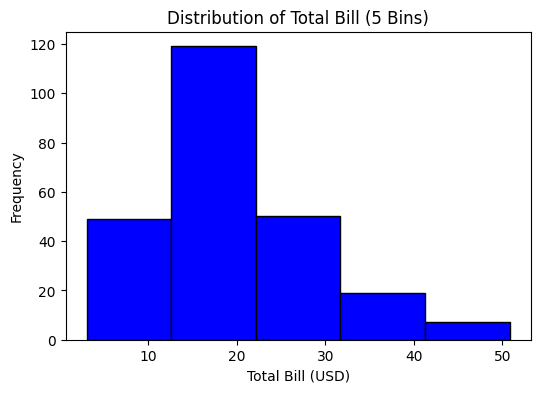

In [11]:
plt.figure(figsize=(6,4))

plt.hist(df["total_bill"], bins=5, color="blue", edgecolor="black")

plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Bill (5 Bins)")

plt.show()

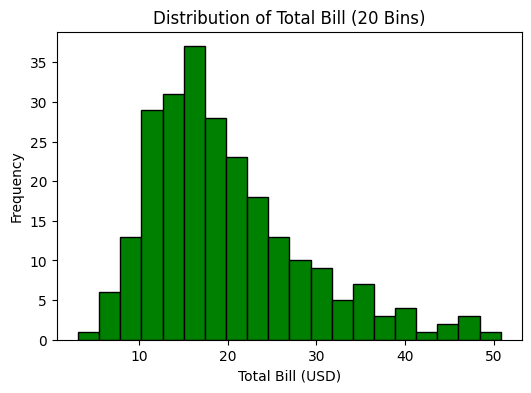

In [12]:
plt.figure(figsize=(6,4))

plt.hist(df["total_bill"], bins=20, color="green", edgecolor="black")

plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Bill (20 Bins)")

plt.show()

### Interpretation of the Distribution

The distribution of the **total_bill** variable appears to be **right-skewed (positively skewed)**. Most restaurant bills fall within the lower to medium range, while a smaller number of bills are significantly higher. These higher values extend the tail toward the right side of the distribution.

### Effect of Changing the Number of Bins

Changing the number of bins affects how clearly we can interpret the distribution.

- With **5 bins**, the histogram provides a general overview of the data but hides detailed patterns.
- With **20 bins**, the histogram reveals more detailed variations and clusters within the bill values.

Therefore, increasing the number of bins improves the level of detail in the visualization, although too many bins may make the plot harder to interpret.

# Task 2: Outlier Detection Using Box Plots

Box plots are useful for comparing distributions across categories and detecting outliers.

They display the **median, quartiles, and potential outliers** in the data.

In this task, a box plot is used to compare the distribution of **total bill values across different days of the week**.# Task 2: Outlier Detection Using Box Plots

Box plots summarize the distribution of data using quartiles and help identify potential outliers.

In this task, we compare the distribution of **total_bill** across different days of the week.

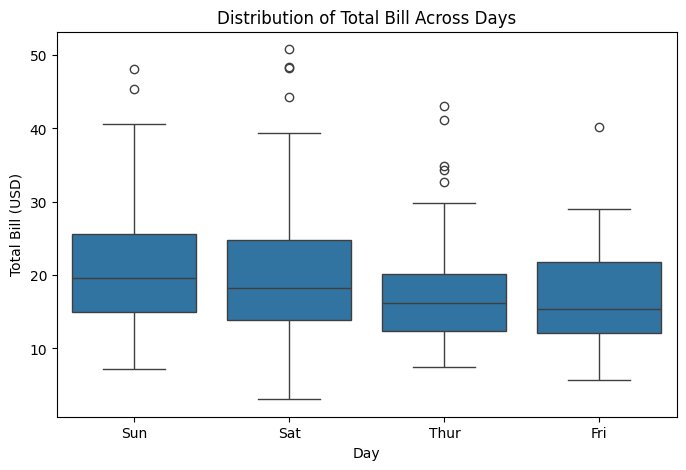

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x="day", y="total_bill", data=df)

plt.xlabel("Day")
plt.ylabel("Total Bill (USD)")
plt.title("Distribution of Total Bill Across Days")

plt.show()

### Highest Median Total Bill

From the box plot, **Saturday appears to have the highest median total bill** compared to the other days. This indicates that customers tend to spend more on average during Saturday dining sessions.

In [14]:
# Calculate quartiles for each day
grouped = df.groupby("day")["total_bill"]

Q1 = grouped.quantile(0.25)
Q3 = grouped.quantile(0.75)

IQR = Q3 - Q1

iqr_table = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR
})

iqr_table

,Q1,Q3,IQR
day,,,
Fri,12.0950,21.7500,9.6550
Sat,13.9050,24.7400,10.8350
Sun,14.9875,25.5975,10.6100
Thur,12.4425,20.1550,7.7125


In [15]:
# Example: Checking outliers for Saturday

sat = df[df["day"] == "Sat"]["total_bill"]

Q1 = sat.quantile(0.25)
Q3 = sat.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify outliers
outliers = sat[(sat < lower_bound) | (sat > upper_bound)]

outliers

Lower Bound: -2.3475
Upper Bound: 40.99250000000001


,total_bill
59,48.27
102,44.30
170,50.81
212,48.33


### Outlier Identification

Using the IQR method:

IQR = Q3 − Q1

Outliers are defined as values outside the range:

Lower Bound = Q1 − 1.5 × IQR  
Upper Bound = Q3 + 1.5 × IQR

The calculated bounds help identify unusually high or low total bill values. The points that fall outside this range correspond to the dots shown outside the whiskers in the box plot, confirming that they are statistical outliers.

# Task 3: Multi-Variable Comparison Using an Interactive Plot

Scatter plots help analyze relationships between numerical variables.

In this task, we create an **interactive scatter plot** using Plotly to explore the relationship between **total_bill and tip**, while also visualizing differences between lunch and dinner transactions.

In [16]:
import plotly.express as px

fig = px.scatter(
    df,
    x="total_bill",
    y="tip",
    color="time",
    hover_data=["day","size"],
    title="Relationship Between Total Bill and Tip"
)

fig.show()

### Relationship Between Total Bill and Tip

The scatter plot shows a **positive relationship between total_bill and tip**. As the total bill increases, the tip amount generally increases as well. This suggests that customers tend to tip proportionally to the size of their bill.

### Difference Between Lunch and Dinner Transactions

The color separation shows that **Dinner transactions occur more frequently at higher bill values**, while Lunch transactions generally involve smaller bills. This indicates that dinner meals tend to involve larger spending and higher tips.

### Interesting Data Point

One interesting observation is a transaction with a **very high total bill but a relatively smaller tip compared to similar bills**. This point deviates from the overall trend and highlights variability in individual tipping behavior.

# Conclusion

This exploratory data analysis helped reveal key patterns in the Tips dataset. The histogram analysis showed that restaurant bills follow a right-skewed distribution. The box plot comparison indicated that Saturday tends to have higher median bill amounts and includes some outliers. Finally, the interactive scatter plot demonstrated a positive relationship between bill size and tip amount while highlighting differences between lunch and dinner transactions.

EDA provides valuable insights that help analysts better understand the structure and characteristics of a dataset before performing more advanced analyses.